In [7]:
import sys, os

sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("helper"))

from plot_utils import (
    np,
    pd,
    plt,
    save_figure,
    load_file,
    read_config_from_csv,
    list_runs,
    FIGURE_SIZE,
    FIGURE_SIZE_HALF,
    LINE_STYLE,
    GRID_STYLE,
    slate_teal,
    deep_red,
    navy,
    bordeaux,
    dark_grey,
)
from analysis import keep_changes

In [8]:
metrics_path = "../metrics"
FIG_DIR = "../figures/evaluation/convergence"
os.makedirs(FIG_DIR, exist_ok=True)

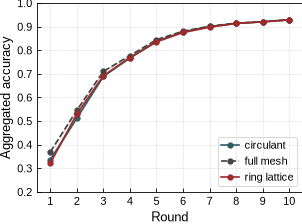

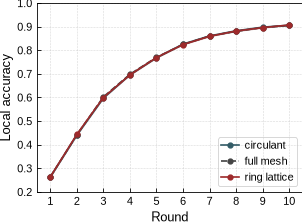

In [9]:
def acc_per_round(df, field):
    acc_rows = df[df.field == field][["timestamp", "node", "value"]].copy()
    acc_rows["acc"] = pd.to_numeric(acc_rows.value, errors="coerce")
    acc_rows = acc_rows.dropna(subset=["acc"])

    rows = []
    for node, node_rows in acc_rows.sort_values(["node", "timestamp"]).groupby("node"):

        changed = keep_changes(node_rows.acc)
        changed.iloc[-1] = True
        node_rows = node_rows[changed]
        node_rows = node_rows[node_rows.acc > 0]

        for round_number, acc_value in enumerate(node_rows.acc.values, start=1):
            rows.append((node, round_number, float(acc_value)))

    return pd.DataFrame(rows, columns=["node", "round", "acc"])


base = os.path.join(metrics_path, "b2_topology_comparison")
rows_topo = []
rows_topo_local = []
for name, path in list_runs(base):
    # I named here runs like "circulant_n32_seed_0"
    topo, sep, seed_str = name.rpartition("_n32_seed_")
    if not sep or not seed_str.isdigit():
        continue
    seed_val = int(seed_str)

    df = load_file(path)

    for row in acc_per_round(df, "aggregated_accuracy").itertuples(index=False):
        rows_topo.append((topo, seed_val, row.node, int(row.round), float(row.acc)))
    for row in acc_per_round(df, "accuracy").itertuples(index=False):
        rows_topo_local.append((topo, seed_val, row.node, int(row.round), float(row.acc)))

# Aggregated accuracy: average over nodes per (topo, seed, round), then over seeds.
df_topo = pd.DataFrame(rows_topo, columns=["topo", "seed", "node", "round", "acc"])
node_mean_topo = df_topo.groupby(["topo", "seed", "round"])["acc"].mean().reset_index()
seed_agg_topo = node_mean_topo.groupby(["topo", "round"])["acc"].agg(["mean", "min", "max", "count"]).reset_index()

df_topo_local = pd.DataFrame(rows_topo_local, columns=["topo", "seed", "node", "round", "acc"])
node_mean_topo_local = df_topo_local.groupby(["topo", "seed", "round"])["acc"].mean().reset_index()
seed_agg_topo_local = (
    node_mean_topo_local.groupby(["topo", "round"])["acc"].agg(["mean", "min", "max", "count"]).reset_index()
)

fm_round10 = seed_agg_topo[(seed_agg_topo.topo == "full_mesh") & (seed_agg_topo["round"] == 10)]

color_by_topo = {"circulant": slate_teal, "ring_lattice": deep_red, "full_mesh": dark_grey}
TOPO_ROUND_XLIM = (0.5, 10.5)
TOPO_ROUND_TICKS = list(range(1, 11))
ACC_YLIM = (0.2, 1.0)


def plot_topo(seed_agg, ylabel, out_name):
    fig, ax = plt.subplots(figsize=FIGURE_SIZE_HALF)

    for topo in sorted(seed_agg.topo.unique()):
        sub = seed_agg[seed_agg.topo == topo].sort_values("round")
        sub = sub[sub["round"] <= TOPO_ROUND_TICKS[-1]]

        color = color_by_topo.get(topo, slate_teal)
        label = topo.replace("_", " ")

        style = dict(LINE_STYLE)
        if topo == "full_mesh":
            style["linestyle"] = "--"

        ax.plot(sub["round"], sub["mean"], color=color, marker="o", markersize=3.5, label=label, **style)

        multi_seed = sub[sub["count"] >= 2]
        if not multi_seed.empty:
            ax.fill_between(multi_seed["round"], multi_seed["min"], multi_seed["max"], color=color, alpha=0.20)

    ax.set_xlabel("Round")
    ax.set_ylabel(ylabel)
    ax.grid(**GRID_STYLE)

    ax.legend(loc="lower right", framealpha=0.9)
    ax.set_xlim(*TOPO_ROUND_XLIM)
    ax.set_xticks(TOPO_ROUND_TICKS)
    ax.set_ylim(*ACC_YLIM)

    fig.tight_layout()
    save_figure(fig, os.path.join(FIG_DIR, out_name))
    plt.show()


plot_topo(seed_agg_topo, "Aggregated accuracy", "accuracy_vs_round_by_topology.pdf")
plot_topo(seed_agg_topo_local, "Local accuracy", "local_accuracy_vs_round_by_topology.pdf")

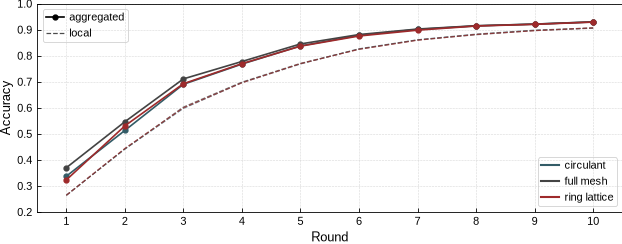

In [10]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=FIGURE_SIZE)
topos = sorted(seed_agg_topo.topo.unique())
for topo in topos:
    color = color_by_topo.get(topo, slate_teal)

    aggregated = seed_agg_topo[seed_agg_topo.topo == topo].sort_values("round")
    aggregated = aggregated[aggregated["round"] <= TOPO_ROUND_TICKS[-1]]

    local = seed_agg_topo_local[seed_agg_topo_local.topo == topo].sort_values("round")
    local = local[local["round"] <= TOPO_ROUND_TICKS[-1]]

    ax.plot(aggregated["round"], aggregated["mean"], color=color, marker="o", markersize=3.5, **LINE_STYLE)
    ax.plot(local["round"], local["mean"], color=color, linestyle="--", linewidth=0.9, alpha=0.7)

color_handles = [Line2D([0], [0], color=color_by_topo[t], linewidth=1.5, label=t.replace("_", " ")) for t in topos]
style_handles = [
    Line2D([0], [0], color="black", linewidth=1.2, marker="o", markersize=3.5, label="aggregated"),
    Line2D([0], [0], color="black", linewidth=0.9, linestyle="--", alpha=0.7, label="local"),
]

leg1 = ax.legend(handles=color_handles, loc="lower right", framealpha=0.9)

ax.add_artist(leg1)
ax.legend(handles=style_handles, loc="upper left", framealpha=0.9)

ax.set_xlabel("Round")
ax.set_ylabel("Accuracy")

ax.grid(**GRID_STYLE)
ax.set_xlim(*TOPO_ROUND_XLIM)
ax.set_xticks(TOPO_ROUND_TICKS)
ax.set_ylim(*ACC_YLIM)

fig.tight_layout()

save_figure(fig, os.path.join(FIG_DIR, "accuracy_overlap_by_topology.pdf"))
plt.show()

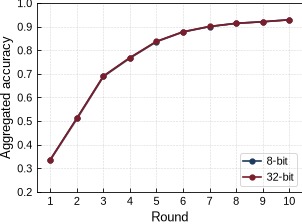

In [6]:
base = os.path.join(metrics_path, "b2_quantization_toggle")
rows_q = []
rows_q_local = []

for name, path in list_runs(base):

    if not name.startswith("qbits_"):
        continue

    # run names look here like "qbits_08_seed_0" or "qbits_32_seed_0_fashion_mnist"
    rest = name[len("qbits_"):]
    dataset = "mnist"

    if rest.endswith("_fashion_mnist"):
        dataset = "fashion_mnist"
        rest = rest[:-len("_fashion_mnist")]

    qbits_str, sep, seed_str = rest.partition("_seed_")

    if not sep or len(qbits_str) != 2 or not qbits_str.isdigit() or not seed_str.isdigit():
        continue

    qbits = int(qbits_str)
    seed_val = int(seed_str)

    df = load_file(path)

    for row in acc_per_round(df, "aggregated_accuracy").itertuples(index=False):
        rows_q.append((dataset, qbits, seed_val, row.node, int(row.round), float(row.acc)))

    for row in acc_per_round(df, "accuracy").itertuples(index=False):
        rows_q_local.append((dataset, qbits, seed_val, row.node, int(row.round), float(row.acc)))

df_q = pd.DataFrame(rows_q, columns=["dataset", "qbits", "seed", "node", "round", "acc"])
seed_agg_q = (
    df_q.groupby(["dataset", "qbits", "seed", "round"])["acc"]
    .mean()
    .reset_index()
    .groupby(["dataset", "qbits", "round"])["acc"]
    .agg(["mean", "min", "max", "count"])
    .reset_index()
)

df_q_local = pd.DataFrame(rows_q_local, columns=["dataset", "qbits", "seed", "node", "round", "acc"])
seed_agg_qL = (
    df_q_local.groupby(["dataset", "qbits", "seed", "round"])["acc"]
    .mean()
    .reset_index()
    .groupby(["dataset", "qbits", "round"])["acc"]
    .agg(["mean", "min", "max", "count"])
    .reset_index()
)

color_by_q = {8: navy, 32: bordeaux}
QUANT_ROUND_XLIM = (0.5, 10.5)
QUANT_ROUND_TICKS = list(range(1, 11))


def plot_qbits_mnist(seed_agg, ylabel, out_name):
    mnist = seed_agg[seed_agg.dataset == "mnist"]

    fig, ax = plt.subplots(figsize=FIGURE_SIZE_HALF)
    for qbits in sorted(mnist.qbits.unique()):

        sub = mnist[mnist.qbits == qbits].sort_values("round")
        sub = sub[sub["round"] <= QUANT_ROUND_TICKS[-1]]

        color = color_by_q.get(qbits, navy)
        ax.plot(sub["round"], sub["mean"], color=color, marker="o", markersize=3.5, label=f"{qbits}-bit", **LINE_STYLE)

        multi_seed = sub[sub["count"] >= 2]
        if not multi_seed.empty:
            ax.fill_between(multi_seed["round"], multi_seed["min"], multi_seed["max"], color=color, alpha=0.20)

    ax.set_xlabel("Round")
    ax.set_ylabel(ylabel)
    ax.grid(**GRID_STYLE)
    ax.legend(loc="lower right", framealpha=0.9)

    ax.set_xlim(*QUANT_ROUND_XLIM)
    ax.set_xticks(QUANT_ROUND_TICKS)
    ax.set_ylim(*ACC_YLIM)
    fig.tight_layout()

    save_figure(fig, os.path.join(FIG_DIR, out_name))

    plt.show()


plot_qbits_mnist(seed_agg_q, "Aggregated accuracy", "accuracy_vs_round_by_qbits.pdf")

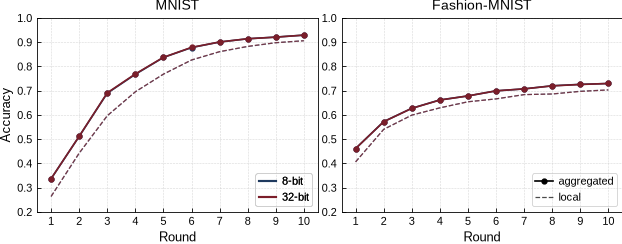

In [11]:
DATASET_LABEL = {"mnist": "MNIST", "fashion_mnist": "Fashion-MNIST"}

fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE)

for ax, dataset in zip(axes, ["mnist", "fashion_mnist"]):

    for q in sorted(df_q.qbits.unique()):
        color = color_by_q.get(q, navy)

        aggregated = seed_agg_q[(seed_agg_q.dataset == dataset) & (seed_agg_q.qbits == q)].sort_values("round")
        local = seed_agg_qL[(seed_agg_qL.dataset == dataset) & (seed_agg_qL.qbits == q)].sort_values("round")

        aggregated = aggregated[aggregated["round"] <= QUANT_ROUND_TICKS[-1]]
        local = local[local["round"] <= QUANT_ROUND_TICKS[-1]]

        ax.plot(aggregated["round"], aggregated["mean"], color=color, marker="o", markersize=3.5, **LINE_STYLE)
        ax.plot(local["round"], local["mean"], color=color, linestyle="--", linewidth=0.9, alpha=0.7)

    ax.set_xlabel("Round")
    ax.set_title(DATASET_LABEL[dataset])
    ax.grid(**GRID_STYLE)

    ax.set_xlim(*QUANT_ROUND_XLIM)
    ax.set_xticks(QUANT_ROUND_TICKS)
    ax.set_ylim(*ACC_YLIM)

axes[0].set_ylabel("Accuracy")

color_handles = [
    Line2D([0], [0], color=color_by_q[q], linewidth=1.5, label=f"{q}-bit") for q in sorted(df_q.qbits.unique())
]

style_handles = [
    Line2D([0], [0], color="black", linewidth=1.2, marker="o", markersize=3.5, label="aggregated"),
    Line2D([0], [0], color="black", linewidth=0.9, linestyle="--", alpha=0.7, label="local"),
]

leg1 = axes[0].legend(handles=color_handles, loc="lower right", framealpha=0.9)
axes[0].add_artist(leg1)
axes[1].legend(handles=style_handles, loc="lower right", framealpha=0.9)

fig.tight_layout()

save_figure(fig, os.path.join(FIG_DIR, "accuracy_overlap_by_qbits.pdf"))
plt.show()